In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import json
import math
import os
import shutil
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import xgboost

from aeroguard.donnees_ml import preparer_xy
from aeroguard.hybride import centrer_par_moteur

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
morceaux = [preparer_xy(vols, g) for g in ("train", "val", "test")]
X_tous = pd.concat([X for X, _ in morceaux])                  # garde les NaN (XGBoost les gère)
y_np = pd.concat([y for _, y in morceaux]).to_numpy()
infos = vols.loc[X_tous.index, ["moteur", "cycle", "RUL"]]
famille = vols.loc[X_tous.index, "famille"].astype(str).to_numpy()
groupe = vols.loc[X_tous.index, "groupe"].to_numpy()
est_train, est_val, est_test = (groupe == "train"), (groupe == "val"), (groupe == "test")
sains = y_np == 0

# Pour les autoencodeurs : NaN remplacés par la médiane du TRAIN (30 vols de DS02_14 en test)
medianes = morceaux[0][0].median()
X_np = X_tous.fillna(medianes).to_numpy(dtype="float64")
moteurs = infos["moteur"].to_numpy()
cycles = infos["cycle"].to_numpy()

N_PREMIERS = 10
rang = infos.groupby("moteur")["cycle"].rank(method="first").to_numpy()
suivi = rang > N_PREMIERS
X_centre = centrer_par_moteur(X_np, moteurs, cycles, n_premiers=N_PREMIERS)

premiers_sains = pd.Series(sains[~suivi]).groupby(moteurs[~suivi]).mean()
print("Moteurs :", {g: len(np.unique(moteurs[groupe == g])) for g in ("train", "val", "test")})
print("Moteurs dont les 10 premiers vols ne sont pas tous sains :", int((premiers_sains < 1).sum()))

Mounted at /content/drive
Moteurs : {'train': 49, 'val': 11, 'test': 39}
Moteurs dont les 10 premiers vols ne sont pas tous sains : 0


In [3]:
from aeroguard.anomalies import seuil_percentile
from aeroguard.autoencodeurs import (creer_autoencodeur_dense, erreur_reconstruction, standardiser,
                                     statistiques_features)
from aeroguard.reseaux import creer_callbacks

PERCENTILE_AE, K_AE = 90, 5
SEUIL_XGB, K_XGB = 0.81, 3


def entrainer_ae_centre(apprentissage, calibration):
    """Recette figée en 5.5 : vols sains centrés, seuil p90 sur les vols sains de calibration."""
    moyennes, ecarts = statistiques_features(X_centre[apprentissage])
    Xn = standardiser(X_centre, moyennes, ecarts)
    ae = creer_autoencodeur_dense(Xn.shape[1])
    ae.fit(Xn[apprentissage], Xn[apprentissage], validation_data=(Xn[calibration], Xn[calibration]),
           epochs=300, batch_size=64, callbacks=creer_callbacks(patience=20), verbose=0)
    erreurs = erreur_reconstruction(ae, Xn)
    return ae, moyennes, ecarts, erreurs, seuil_percentile(erreurs[calibration], PERCENTILE_AE)


ae_centre, moy_c, ecarts_c, erreurs_centre, seuil_centre = entrainer_ae_centre(
    est_train & sains & suivi, est_val & sains & suivi)

CHEMIN_AE = f"{DOSSIER}/models/autoencodeur_centre_v5.keras"
CHEMIN_STATS = f"{DOSSIER}/models/autoencodeur_centre_v5_stats.npz"
CHEMIN_CONFIG = f"{DOSSIER}/models/autoencodeur_centre_v5_alerte.json"
ae_centre.save(CHEMIN_AE)
np.savez(CHEMIN_STATS, moyennes=moy_c, ecarts=ecarts_c, medianes_imputation=medianes.to_numpy(),
         colonnes=np.array(X_tous.columns, dtype=str))
CONFIG_CENTRE = {"n_premiers": N_PREMIERS, "percentile": PERCENTILE_AE, "seuil": float(seuil_centre),
                 "k": K_AE, "calibre_sur": "vols sains de validation, après leur ligne de base"}
with open(CHEMIN_CONFIG, "w") as f:
    json.dump(CONFIG_CENTRE, f, indent=2)
print("Configuration figée AVANT le test :", CONFIG_CENTRE)

Configuration figée AVANT le test : {'n_premiers': 10, 'percentile': 90, 'seuil': 0.6182578802108765, 'k': 5, 'calibre_sur': 'vols sains de validation, après leur ligne de base'}


In [4]:
from aeroguard.autoencodeurs import standardiser
from aeroguard.comparaison import bootstrap_moteurs, comparer_a_reference, intervalle_confiance
from aeroguard.evaluation import metriques
from aeroguard.metier import alertes_confirmees, bilan_flotte, evaluer_alerte, resume_flotte


def confirmer(alertes_brutes, masque, k):
    """Alertes confirmées sur k vols d'affilée, moteur par moteur, sur les vols du masque."""
    table = infos[masque].assign(alerte=np.asarray(alertes_brutes).astype(int)).sort_values(["moteur", "cycle"])
    table["confirmee"] = table.groupby("moteur")["alerte"].transform(lambda s: alertes_confirmees(s.to_numpy(), k))
    return table["confirmee"].reindex(infos[masque].index).to_numpy()


def resumer(confirmees, masque):
    """Bilan métier (moteurs prévenus, avance, fausses alarmes) + F1 macro par vol."""
    table = infos[masque].assign(y=y_np[masque], alerte=confirmees)
    return {**resume_flotte(bilan_flotte(table, col_moteur="moteur", k=1)),
            "f1_macro": metriques(y_np[masque], confirmees)["f1_macro"]}


# Contrôle de reproductibilité : XGBoost v3 doit redonner 0.852 sur le test (comme en 3.6 et 4.7)
xgb_v3 = xgboost.XGBClassifier()
xgb_v3.load_model(f"{DOSSIER}/models/xgb_binaire_v3.json")
xgb_v3.set_params(device="cpu")
probas_xgb = xgb_v3.predict_proba(X_tous)[:, 1]
controle = evaluer_alerte(y_np[est_test], probas_xgb[est_test], SEUIL_XGB, infos[est_test], k=K_XGB,
                          col_moteur="moteur")
print(f"Contrôle XGBoost v3 sur le test : F1 macro {controle['f1_macro']:.3f} (attendu 0.852)")

# Autoencodeur standard v5 (5.1 + seuil figé en 5.2)
from tensorflow import keras
ae_std = keras.models.load_model(f"{DOSSIER}/models/autoencodeur_dense_v5.keras")
stats_std = np.load(f"{DOSSIER}/models/autoencodeur_dense_v5_stats.npz", allow_pickle=True)
with open(f"{DOSSIER}/models/autoencodeur_dense_v5_alerte.json") as f:
    config_std = json.load(f)
erreurs_std = erreur_reconstruction(ae_std, standardiser(X_np, stats_std["moyennes"], stats_std["ecarts"]))

# Évaluation : moteurs de test, après leur ligne de base (mêmes vols pour tous les systèmes)
evaluation = est_test & suivi
alertes = {
    "xgboost_v3": confirmer(probas_xgb[evaluation] >= SEUIL_XGB, evaluation, K_XGB),
    "ae_standard": confirmer(erreurs_std[evaluation] > config_std["seuil"], evaluation, config_std["k"]),
    "ae_centre": confirmer(erreurs_centre[evaluation] > seuil_centre, evaluation, K_AE),
}
alertes["hybride"] = np.maximum(alertes["xgboost_v3"], alertes["ae_centre"])

test_connues = pd.DataFrame({nom: resumer(conf, evaluation) for nom, conf in alertes.items()}).T
tirages = bootstrap_moteurs(moteurs[evaluation], y_np[evaluation], alertes, n_tirages=1000, graine=42)
for nom in alertes:
    test_connues.loc[nom, "ic95_bas"], test_connues.loc[nom, "ic95_haut"] = intervalle_confiance(tirages[nom])
colonnes = ["moteurs", "moteurs_detectes", "avance_moyenne", "fausses_alarmes_total",
            "moteurs_avec_fausse_alarme", "f1_macro", "ic95_bas", "ic95_haut"]
display(test_connues[colonnes].round(3))
print("\nÉcart de F1 à XGBoost v3 (bootstrap par moteur) :")
comparer_a_reference(tirages, "xgboost_v3").round(3)

Contrôle XGBoost v3 sur le test : F1 macro 0.852 (attendu 0.852)


,moteurs,moteurs_detectes,avance_moyenne,fausses_alarmes_total,moteurs_avec_fausse_alarme,f1_macro,ic95_bas,ic95_haut
xgboost_v3,39.0,39.0,40.051,26.0,4.0,0.783,0.746,0.818
ae_standard,39.0,39.0,29.205,6.0,1.0,0.654,0.634,0.673
ae_centre,39.0,39.0,32.513,7.0,2.0,0.692,0.667,0.719
hybride,39.0,39.0,40.795,29.0,5.0,0.791,0.755,0.827



Écart de F1 à XGBoost v3 (bootstrap par moteur) :


,f1_macro_moyen,ecart_moyen,ecart_bas,ecart_haut,proba_meilleur,difference_prouvee
modele,,,,,,
xgboost_v3,0.783,0.000,0.000,0.000,0.000,False
ae_standard,0.654,-0.129,-0.150,-0.105,0.000,True
ae_centre,0.692,-0.091,-0.114,-0.065,0.000,True
hybride,0.792,0.009,0.000,0.020,0.977,True


In [5]:
from aeroguard.modeles import creer_xgboost

resultats = []
for famille_retiree in sorted(set(famille)):
    debut = time.perf_counter()
    connue = famille != famille_retiree
    evaluation_f = est_test & ~connue & suivi           # moteurs de TEST de la famille retirée

    xgb = creer_xgboost("cpu", early_stopping_rounds=None, n_estimators=411)
    xgb.fit(X_tous[est_train & connue], y_np[est_train & connue])
    conf_xgb_sans = confirmer(xgb.predict_proba(X_tous[evaluation_f])[:, 1] >= SEUIL_XGB, evaluation_f, K_XGB)

    _, _, _, erreurs_f, seuil_f = entrainer_ae_centre(est_train & connue & sains & suivi,
                                                     est_val & connue & sains & suivi)
    conf_ae_sans = confirmer(erreurs_f[evaluation_f] > seuil_f, evaluation_f, K_AE)

    ligne = {"famille_retiree": famille_retiree}
    for nom, conf in [("xgb_sans", conf_xgb_sans), ("ae_centre_sans", conf_ae_sans),
                      ("hybride_sans", np.maximum(conf_xgb_sans, conf_ae_sans))]:
        bilan = resumer(conf, evaluation_f)
        ligne["moteurs"] = bilan["moteurs"]
        ligne[f"{nom}_detectes"] = bilan["moteurs_detectes"]
        ligne[f"{nom}_avance"] = bilan["avance_moyenne"]
        ligne[f"{nom}_fausses_alarmes"] = bilan["fausses_alarmes_total"]
    resultats.append(ligne)
    print(f"{famille_retiree:8s} → XGBoost {ligne['xgb_sans_detectes']}/{ligne['moteurs']} | "
          f"hybride {ligne['hybride_sans_detectes']}/{ligne['moteurs']} ({time.perf_counter() - debut:.0f} s)")

test_inconnues = pd.DataFrame(resultats).set_index("famille_retiree")
test_inconnues.round(1)

HPC      → XGBoost 4/4 | hybride 4/4 (52 s)
HPT      → XGBoost 4/4 | hybride 4/4 (35 s)
HPT+LPT  → XGBoost 9/9 | hybride 9/9 (41 s)
LPC+HPC  → XGBoost 4/4 | hybride 4/4 (26 s)
LPT      → XGBoost 4/4 | hybride 4/4 (32 s)
fan      → XGBoost 2/4 | hybride 4/4 (30 s)
mixte    → XGBoost 10/10 | hybride 10/10 (27 s)


,moteurs,xgb_sans_detectes,xgb_sans_avance,xgb_sans_fausses_alarmes,ae_centre_sans_detectes,ae_centre_sans_avance,ae_centre_sans_fausses_alarmes,hybride_sans_detectes,hybride_sans_avance,hybride_sans_fausses_alarmes
famille_retiree,,,,,,,,,,
HPC,4,4,40.5,0,4,32.0,0,4,40.5,0
HPT,4,4,41.2,0,4,33.0,0,4,41.2,0
HPT+LPT,9,9,42.4,43,9,41.3,22,9,44.6,52
LPC+HPC,4,4,42.5,0,4,31.0,0,4,42.5,0
LPT,4,4,37.5,0,4,34.8,0,4,37.5,0
fan,4,2,26.0,0,4,39.2,0,4,39.8,0
mixte,10,10,35.3,22,10,23.9,0,10,35.3,22


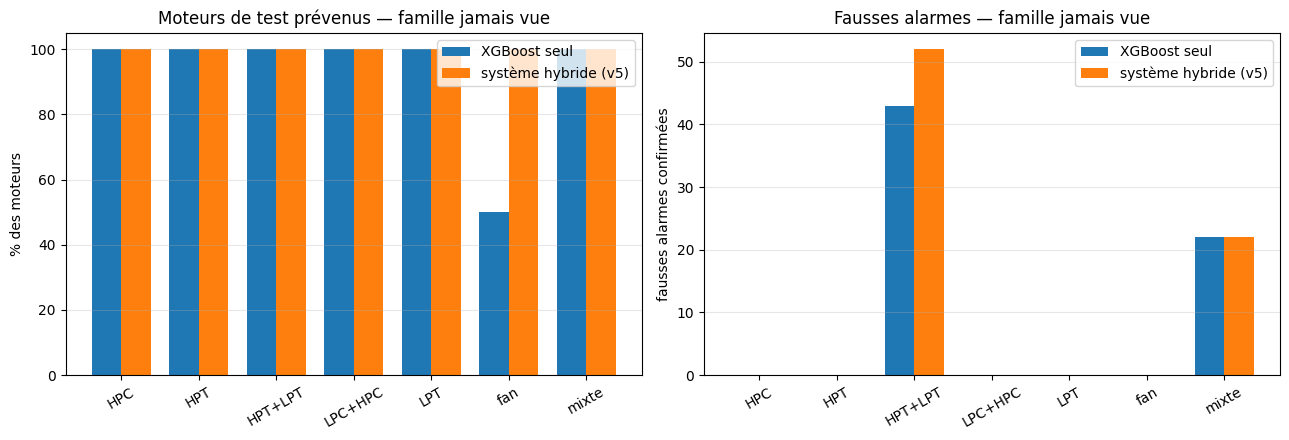

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
positions = np.arange(len(test_inconnues))
largeur = 0.38
pct = lambda colonne: 100 * test_inconnues[colonne] / test_inconnues["moteurs"]
axes[0].bar(positions - largeur / 2, pct("xgb_sans_detectes"), largeur, label="XGBoost seul")
axes[0].bar(positions + largeur / 2, pct("hybride_sans_detectes"), largeur, label="système hybride (v5)")
axes[0].set_title("Moteurs de test prévenus — famille jamais vue")
axes[0].set_ylabel("% des moteurs")
axes[1].bar(positions - largeur / 2, test_inconnues["xgb_sans_fausses_alarmes"], largeur, label="XGBoost seul")
axes[1].bar(positions + largeur / 2, test_inconnues["hybride_sans_fausses_alarmes"], largeur,
            label="système hybride (v5)")
axes[1].set_title("Fausses alarmes — famille jamais vue")
axes[1].set_ylabel("fausses alarmes confirmées")
for axe in axes:
    axe.set_xticks(positions, test_inconnues.index, rotation=30)
    axe.legend()
    axe.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/56_test_panne_inconnue.png", dpi=150)
plt.show()

In [7]:
from mlflow import MlflowClient

from aeroguard.registre import definir_alias, enregistrer_version, lire_alias, uri_alias

NOM_ANOMALIE = "aeroguard-anomalie"
client = MlflowClient()
ligne_ae = test_connues.loc["ae_centre"]

if client.search_model_versions(f"name='{NOM_ANOMALIE}'"):
    print("⚠️ Déjà inscrit : on ne recrée pas de version.")
else:
    mlflow.set_experiment("aeroguard-registre")
    with mlflow.start_run(run_name="autoencodeur_centre_registre"):
        try:
            info = mlflow.keras.log_model(ae_centre, name="model")
            saveur = "keras"
        except Exception as erreur:
            print("mlflow.keras indisponible, on utilise mlflow.tensorflow :", erreur)
            info = mlflow.tensorflow.log_model(ae_centre, name="model")
            saveur = "tensorflow"
        mlflow.log_artifact(CHEMIN_STATS)
        mlflow.log_artifact(CHEMIN_CONFIG)
        mlflow.log_params(CONFIG_CENTRE)
        mlflow.set_tags({"lecon": "5.6", "jeu": "test"})
    version = enregistrer_version(
        info.model_uri, nom=NOM_ANOMALIE,
        description=("Autoencodeur dense avec ligne de base par moteur (10 premiers vols) : garde-fou "
                     "« anomalie inconnue » du système hybride, en complément de aeroguard-alerte@champion."),
        etiquettes={"saveur": saveur, "seuil": CONFIG_CENTRE["seuil"], "fenetre_confirmation": K_AE,
                    "n_premiers": N_PREMIERS, "percentile": PERCENTILE_AE,
                    "moteurs_test_detectes": f"{int(ligne_ae['moteurs_detectes'])}/{int(ligne_ae['moteurs'])}",
                    "fausses_alarmes_test": int(ligne_ae["fausses_alarmes_total"]),
                    "version_projet": "v5", "fichier_stats": "autoencodeur_centre_v5_stats.npz"},
    )
    definir_alias("champion", version, nom=NOM_ANOMALIE)
    print(f"✅ {NOM_ANOMALIE} version {version} → @champion")

# Test de fumée : le modèle rechargé depuis le registre donne les mêmes reconstructions
notice = lire_alias("champion", nom=NOM_ANOMALIE)
recharge = getattr(mlflow, notice["etiquettes"]["saveur"]).load_model(uri_alias("champion", nom=NOM_ANOMALIE))
echantillon = standardiser(X_centre[evaluation][:50], moy_c, ecarts_c)
ecart = np.abs(np.asarray(recharge.predict(echantillon, verbose=0)) - ae_centre.predict(echantillon, verbose=0)).max()
print(f"Écart maximal registre / modèle en mémoire : {ecart:.2e}")
assert ecart < 1e-4, "Le registre ne contient pas le bon modèle !"
print("✅ Test de fumée réussi")

2026/10/09 18:56:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
Successfully registered model 'aeroguard-anomalie'.
Created version '1' of model 'aeroguard-anomalie'.


✅ aeroguard-anomalie version 1 → @champion
Écart maximal registre / modèle en mémoire : 0.00e+00
✅ Test de fumée réussi


In [8]:
def scores_numeriques(scores):
    """Garde seulement les nombres valides (MLflow refuse le texte et les NaN)."""
    propres = {}
    for cle, valeur in scores.items():
        try:
            nombre = float(valeur)
        except (TypeError, ValueError):
            continue
        if not math.isnan(nombre):
            propres[cle] = nombre
    return propres


test_connues.to_csv(f"{DOSSIER}/results/v5_test_alerte.csv")
test_inconnues.to_csv(f"{DOSSIER}/results/v5_test_panne_inconnue.csv")

mlflow.set_experiment("aeroguard-evaluation-finale")
with mlflow.start_run(run_name="v5_test_final") as run:
    mlflow.log_params({"version": "v5", "moteurs_test": 39, "ligne_de_base": f"{N_PREMIERS} premiers vols",
                       "hybride": "XGBoost v3 OU autoencodeur centré"})
    for nom, ligne in test_connues.iterrows():
        mlflow.log_metrics({f"connues_{nom}_{cle}": valeur for cle, valeur in scores_numeriques(ligne).items()})
    for nom, ligne in test_inconnues.iterrows():
        mlflow.log_metrics({f"inconnue_{str(nom).replace('+', '_')}_{cle}": valeur
                            for cle, valeur in scores_numeriques(ligne).items()})
    for chemin in [f"{DOSSIER}/results/v5_test_alerte.csv", f"{DOSSIER}/results/v5_test_panne_inconnue.csv",
                   f"{DOSSIER}/results/figures/56_test_panne_inconnue.png"]:
        mlflow.log_artifact(chemin)
    mlflow.set_tags({"lecon": "5.6", "jeu": "test", "evaluation": "unique"})
print("✅ Résultats v5 enregistrés :", run.info.run_id[:8])

✅ Résultats v5 enregistrés : b16a1814


In [9]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow (runs + registre) sauvegardé sur Drive")

✅ MLflow (runs + registre) sauvegardé sur Drive
